# Zero-Day Detection Experiment: Withheld `Worms` Attacks

This notebook simulates a zero-day scenario using the original UNSW-NB15 data and the trained Autoencoder from Step 3.

**Experiment design**
- `Worms` is deliberately withheld as the unseen attack category. It is uncommon in the dataset, so it represents a realistic novel attack family that the detector did not observe during model development.
- The Step 3 autoencoder was trained only on normal traffic (`label == 0`), and its threshold was calibrated only on normal traffic. No attack category, including `Worms`, is used to fit the model or threshold.
- For evaluation, `Normal` is the benign class, all non-`Worms` attacks are treated as **known attacks**, and `Worms` attacks are treated as **unseen/zero-day attacks**.

The notebook measures whether reconstruction error flags the unseen category as anomalous. It does not implement Federated Learning, SHAP/LIME, threat scoring, or Streamlit.

In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
project_root = Path.cwd().resolve()
for candidate in (project_root, project_root.parent):
    if (candidate / 'dataset' / 'UNSW-NB15').exists():
        project_root = candidate
        break

if not (project_root / 'dataset' / 'UNSW-NB15').exists():
    raise FileNotFoundError('Could not find dataset/UNSW-NB15 from the notebook or its parent folder.')

project_root = project_root.resolve()
data_dir = project_root / 'dataset' / 'UNSW-NB15'
model_dir = project_root / 'models' / 'trained_models'
plots_dir = project_root / 'results' / 'plots'
metrics_dir = project_root / 'results' / 'metrics'
plots_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(data_dir / 'UNSW_NB15_training-set.csv')
test_df = pd.read_csv(data_dir / 'UNSW_NB15_testing-set.csv')
with (project_root / 'models' / 'preprocessing_pipeline.pkl').open('rb') as file:
    preprocessor = pickle.load(file)

model = tf.keras.models.load_model(model_dir / 'autoencoder_model.h5', compile=False)
with (model_dir / 'autoencoder_threshold.pkl').open('rb') as file:
    threshold_metadata = pickle.load(file)
anomaly_threshold = float(threshold_metadata['anomaly_threshold'])

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Loaded threshold: {anomaly_threshold:.6f}')

Train shape: (175341, 45)
Test shape: (82332, 45)
Loaded threshold: 0.001948


In [3]:
WITHHELD_CATEGORY = 'Worms'
feature_cols = [column for column in train_df.columns if column not in ('label', 'attack_cat')]

# This assertion documents the experiment boundary: withheld attacks cannot enter model development.
withheld_train_count = int((train_df['attack_cat'] == WITHHELD_CATEGORY).sum())
assert withheld_train_count > 0
assert WITHHELD_CATEGORY not in train_df.loc[train_df['label'] == 0, 'attack_cat'].unique()

# The Step 3 model was fit on normal rows only; no attack rows are used here either.
normal_train = train_df[train_df['label'] == 0]
X_normal_train = np.asarray(preprocessor.transform(normal_train[feature_cols]), dtype=np.float32)
assert len(normal_train) == int((train_df['attack_cat'] == 'Normal').sum())

X_test = np.asarray(preprocessor.transform(test_df[feature_cols]), dtype=np.float32)
test_categories = test_df['attack_cat'].astype(str).to_numpy()
y_test = test_df['label'].astype(int).to_numpy()

known_attack_mask = (y_test == 1) & (test_categories != WITHHELD_CATEGORY)
unseen_attack_mask = test_categories == WITHHELD_CATEGORY
normal_test_mask = y_test == 0

print(f'Withheld category: {WITHHELD_CATEGORY}')
print(f'Withheld training rows excluded from model development: {withheld_train_count}')
print(f'Normal training rows available to Step 3: {len(X_normal_train)}')
print(f'Test rows: normal={normal_test_mask.sum()}, known attacks={known_attack_mask.sum()}, unseen attacks={unseen_attack_mask.sum()}')

Withheld category: Worms
Withheld training rows excluded from model development: 130
Normal training rows available to Step 3: 56000
Test rows: normal=37000, known attacks=45288, unseen attacks=44


In [4]:
def reconstruction_error(features):
    reconstructed = model.predict(features, batch_size=1024, verbose=0)
    return np.mean(np.square(features - reconstructed), axis=1)

# Only reconstruction errors are used to detect attacks. Test labels/categories are reserved for evaluation.
test_errors = reconstruction_error(X_test)
y_test_pred = (test_errors > anomaly_threshold).astype(int)

results_df = test_df[['attack_cat', 'label']].copy()
results_df['reconstruction_error'] = test_errors
results_df['predicted_anomaly'] = y_test_pred
results_df['group'] = np.select(
    [normal_test_mask, unseen_attack_mask],
    ['Normal', 'Unseen: Worms'],
    default='Known attack',
)

print(results_df.groupby('group', sort=False)['predicted_anomaly'].agg(['count', 'sum', 'mean']).rename(
    columns={'sum': 'detected_anomalies', 'mean': 'detection_rate'}
).to_string(float_format=lambda value: f'{value:.4f}'))

               count  detected_anomalies  detection_rate
group                                                   
Normal         37000                3398          0.0918
Known attack   45288               33592          0.7417
Unseen: Worms     44                  14          0.3182


In [5]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
cm = confusion_matrix(y_test, y_test_pred)
unseen_detection_rate = float(y_test_pred[unseen_attack_mask].mean())
known_detection_rate = float(y_test_pred[known_attack_mask].mean())
normal_false_positive_rate = float(y_test_pred[normal_test_mask].mean())

metrics = pd.DataFrame(
    {
        'metric': [
            'accuracy', 'precision', 'recall', 'f1_score',
            'unseen_attack_detection_rate', 'known_attack_detection_rate',
            'normal_false_positive_rate',
        ],
        'value': [
            accuracy, precision, recall, f1,
            unseen_detection_rate, known_detection_rate, normal_false_positive_rate,
        ],
    }
)
print(metrics.to_string(index=False, float_format=lambda value: f'{value:.4f}'))
print('\nConfusion matrix (rows=true label, columns=predicted label):')
print(cm)
print(f'\nUnseen {WITHHELD_CATEGORY} detection rate: {unseen_detection_rate:.4f}')

                      metric  value
                    accuracy 0.8163
                   precision 0.9082
                      recall 0.7413
                    f1_score 0.8163
unseen_attack_detection_rate 0.3182
 known_attack_detection_rate 0.7417
  normal_false_positive_rate 0.0918

Confusion matrix (rows=true label, columns=predicted label):
[[33602  3398]
 [11726 33606]]

Unseen Worms detection rate: 0.3182


In [6]:
group_summary = results_df.groupby('group', sort=False).agg(
    samples=('predicted_anomaly', 'size'),
    mean_reconstruction_error=('reconstruction_error', 'mean'),
    median_reconstruction_error=('reconstruction_error', 'median'),
    detected_anomalies=('predicted_anomaly', 'sum'),
)
group_summary['detection_rate'] = group_summary['detected_anomalies'] / group_summary['samples']
group_summary.to_csv(metrics_dir / '04_zero_day_group_comparison.csv')
metrics.to_csv(metrics_dir / '04_zero_day_metrics.csv', index=False)
with (metrics_dir / '04_zero_day_experiment.json').open('w', encoding='utf-8') as file:
    json.dump(
        {
            'withheld_category': WITHHELD_CATEGORY,
            'reason': 'Worms is a rare attack category withheld to simulate an unseen attack family.',
            'training_rows_withheld': withheld_train_count,
            'test_rows_unseen': int(unseen_attack_mask.sum()),
            'threshold': anomaly_threshold,
            'metrics': dict(zip(metrics['metric'], metrics['value'])),
            'confusion_matrix': cm.tolist(),
        },
        file,
        indent=2,
    )

print(f'Results saved under {metrics_dir}')

Results saved under C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\metrics


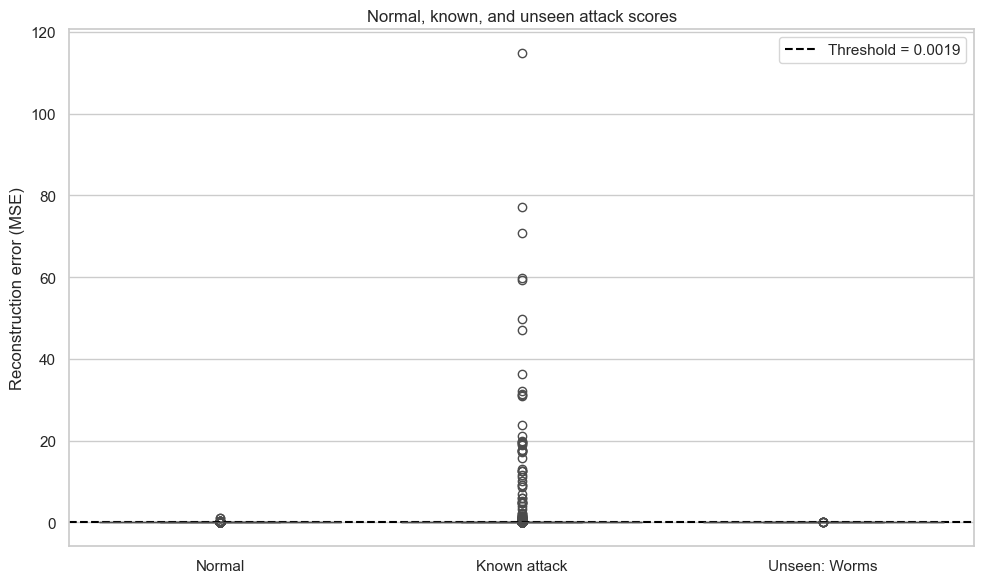

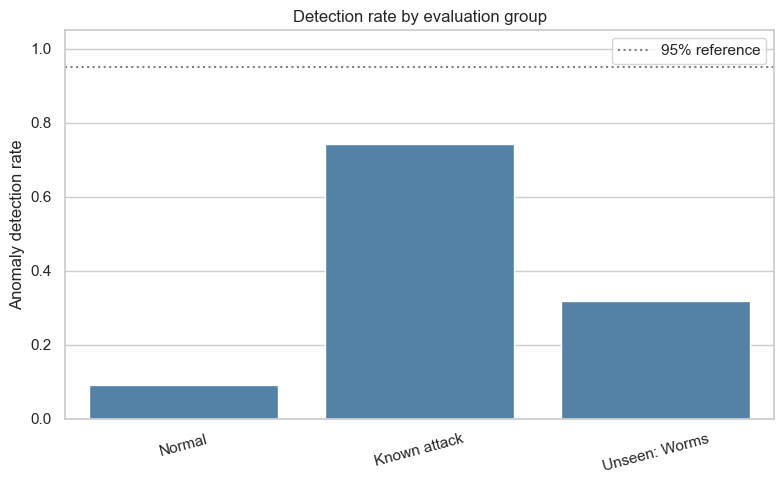

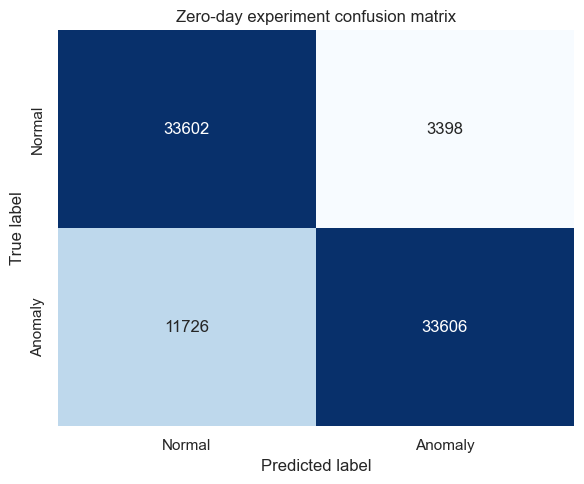

Plots saved under C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\plots


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=results_df, x='group', y='reconstruction_error', order=['Normal', 'Known attack', 'Unseen: Worms'], ax=ax)
ax.axhline(anomaly_threshold, color='black', linestyle='--', label=f'Threshold = {anomaly_threshold:.4f}')
ax.set(xlabel='', ylabel='Reconstruction error (MSE)', title='Normal, known, and unseen attack scores')
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / '04_zero_day_error_comparison.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_summary = group_summary.reset_index()
sns.barplot(data=plot_summary, x='group', y='detection_rate', ax=ax, color='steelblue')
ax.axhline(0.95, color='gray', linestyle=':', label='95% reference')
ax.set(xlabel='', ylabel='Anomaly detection rate', ylim=(0, 1.05), title='Detection rate by evaluation group')
ax.tick_params(axis='x', rotation=15)
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / '04_zero_day_detection_rates.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
ax.set(xlabel='Predicted label', ylabel='True label', title='Zero-day experiment confusion matrix')
fig.tight_layout()
fig.savefig(plots_dir / '04_zero_day_confusion_matrix.png', dpi=200)
plt.show()

print(f'Plots saved under {plots_dir}')